# Movie Revenue and Audience Engagement Analysis

This notebook analyzes how production budget, release year, audience engagement, ratings, genre, and worldwide gross are related in a historical movie dataset.

The analysis is organized as a reproducible workflow:

1. Load and inspect the raw data.
2. Clean missing values, numeric fields, and release dates.
3. Validate the cleaned dataset.
4. Explore distributions and genre composition.
5. Analyze relationships between budget, revenue, ratings, and audience engagement.
6. Summarize findings and limitations.

The dataset is kept separate from the notebook in `../data/movies.csv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42
DATA_PATH = Path("../data/movies.csv")

In [2]:
raw_movies = pd.read_csv(DATA_PATH)

print(
    f"Loaded {raw_movies.shape[0]:,} movie records "
    f"with {raw_movies.shape[1]} source columns."
)
raw_movies.head(3)

Loaded 3,201 movie records with 16 source columns.


,Title,US Gross,Worldwide Gross,US DVD Sales,Production Budget,Release Date,MPAA Rating,Running Time (min),Distributor,Source,Major Genre,Creative Type,Director,Rotten Tomatoes Rating,IMDB Rating,IMDB Votes
0,The Land Girls,146083,146083,NaN,8000000.0,12-Jun-98,R,NaN,Gramercy,NaN,NaN,NaN,NaN,NaN,6.1,1071.0
1,"First Love, Last Rites",10876,10876,NaN,300000.0,7-Aug-98,R,NaN,Strand,NaN,Drama,NaN,NaN,NaN,6.9,207.0
2,I Married a Strange Person,203134,203134,NaN,250000.0,28-Aug-98,NaN,NaN,Lionsgate,NaN,Comedy,NaN,NaN,NaN,6.8,865.0


In [3]:
column_mapping = {
    "Title": "title",
    "US Gross": "us_gross",
    "Worldwide Gross": "worldwide_gross",
    "US DVD Sales": "us_dvd_sales",
    "Production Budget": "production_budget",
    "Release Date": "release_date",
    "MPAA Rating": "mpaa_rating",
    "Running Time (min)": "running_time_minutes",
    "Distributor": "distributor",
    "Source": "source",
    "Major Genre": "major_genre",
    "Creative Type": "creative_type",
    "Director": "director",
    "Rotten Tomatoes Rating": "rotten_tomatoes_rating",
    "IMDB Rating": "imdb_rating",
    "IMDB Votes": "imdb_votes",
}

movies = raw_movies.rename(columns=column_mapping).copy()

print(f"Standardized {len(movies.columns)} column names for analysis.")
pd.DataFrame(
    {"source_column": raw_movies.columns, "analysis_column": movies.columns}
)

Standardized 16 column names for analysis.


,source_column,analysis_column
0,Title,title
1,US Gross,us_gross
2,Worldwide Gross,worldwide_gross
3,US DVD Sales,us_dvd_sales
4,Production Budget,production_budget
5,Release Date,release_date
6,MPAA Rating,mpaa_rating
7,Running Time (min),running_time_minutes
8,Distributor,distributor
9,Source,source


In [4]:
numeric_columns = [
    "us_gross",
    "worldwide_gross",
    "us_dvd_sales",
    "production_budget",
    "running_time_minutes",
    "rotten_tomatoes_rating",
    "imdb_rating",
    "imdb_votes",
]

missing_markers = ["Unknown", "unknown", "TBD", "tbd", ""]
movies = movies.replace(missing_markers, np.nan)

for column in numeric_columns:
    movies[column] = pd.to_numeric(movies[column], errors="coerce")

movies["release_date"] = pd.to_datetime(
    movies["release_date"],
    format="mixed",
    errors="coerce",
    dayfirst=True,
)

future_date_mask = movies["release_date"].dt.year > pd.Timestamp.today().year
movies.loc[future_date_mask, "release_date"] = movies.loc[
    future_date_mask, "release_date"
].map(lambda date: date.replace(year=date.year - 100))

movies["release_year"] = movies["release_date"].dt.year.astype("Int64")

print(f"Converted numeric fields and parsed release dates for {len(movies):,} records.")
movies[["title", "release_date", "release_year", "production_budget", "worldwide_gross"]].head(3)

Converted numeric fields and parsed release dates for 3,201 records.


,title,release_date,release_year,production_budget,worldwide_gross
0,The Land Girls,1998-06-12,1998,8000000.0,146083.0
1,"First Love, Last Rites",1998-08-07,1998,300000.0,10876.0
2,I Married a Strange Person,1998-08-28,1998,250000.0,203134.0


In [5]:
missing_summary = (
    movies.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .rename("missing_percentage")
    .to_frame()
)
missing_summary.index.name = "column"
missing_summary.columns = ["Missing (%)"]

print("Missing-data profile:")
missing_summary

Missing-data profile:


,Missing (%)
column,
us_dvd_sales,82.4
running_time_minutes,62.2
director,41.6
rotten_tomatoes_rating,27.5
mpaa_rating,18.9
creative_type,13.9
source,11.4
major_genre,8.6
distributor,7.2


In [6]:
before_cleaning = len(movies)

movies = movies.drop_duplicates(subset="title", keep="first").copy()
movies = movies[movies["worldwide_gross"].notna()].copy()

valid_rating = movies["imdb_rating"].between(0, 10) | movies["imdb_rating"].isna()
valid_budget = movies["production_budget"].ge(0) | movies["production_budget"].isna()
valid_gross = movies["worldwide_gross"].ge(0)

movies = movies[valid_rating & valid_budget & valid_gross].copy()

print("Cleaning summary:")
print(f"  Input records:  {before_cleaning:,}")
print(f"  Retained records: {len(movies):,}")
print(f"  Removed records: {before_cleaning - len(movies):,}")

Cleaning summary:
  Input records:  3,201
  Retained records: 3,170
  Removed records: 31


In [7]:
quality_checks = pd.Series(
    {
        "Duplicate titles": movies["title"].duplicated().sum(),
        "Missing worldwide gross": movies["worldwide_gross"].isna().sum(),
        "Negative production budgets": (movies["production_budget"] < 0).sum(),
        "Negative worldwide gross values": (movies["worldwide_gross"] < 0).sum(),
        "Invalid IMDb ratings": (
            ~movies["imdb_rating"].between(0, 10)
            & movies["imdb_rating"].notna()
        ).sum(),
    },
    name="Count",
).to_frame()

print("Post-cleaning quality checks:")
quality_checks

Post-cleaning quality checks:


,Count
Duplicate titles,0
Missing worldwide gross,0
Negative production budgets,0
Negative worldwide gross values,0
Invalid IMDb ratings,0


## Distribution of Worldwide Gross

Worldwide gross is strongly right-skewed: a small number of movies earn substantially more than most titles. This is why later relationship plots include a logarithmic scale.

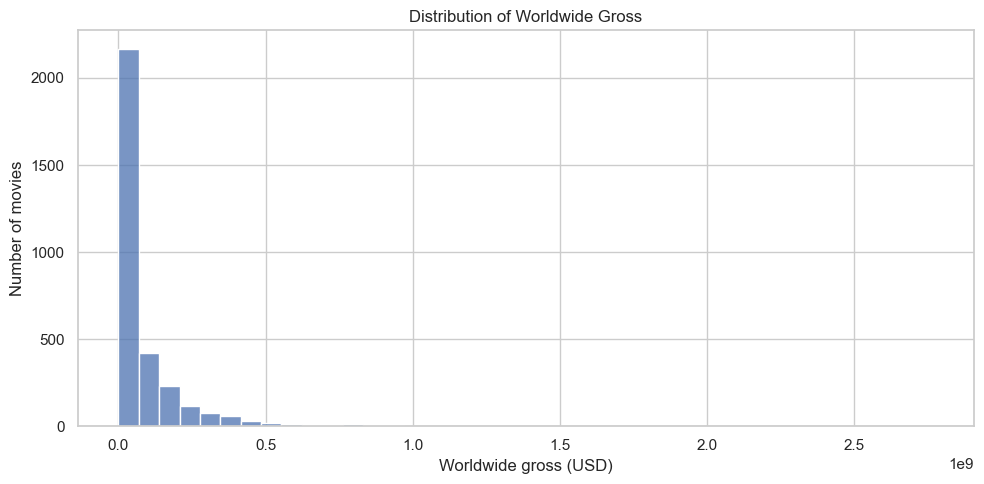

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=movies, x="worldwide_gross", bins=40, ax=ax)
ax.set_title("Distribution of Worldwide Gross")
ax.set_xlabel("Worldwide gross (USD)")
ax.set_ylabel("Number of movies")
plt.tight_layout()
plt.show()

## Ratings and Audience Engagement

Ratings are bounded scores, while IMDb vote counts are highly skewed. The plots below use labels and scales that reflect those different measurement properties.

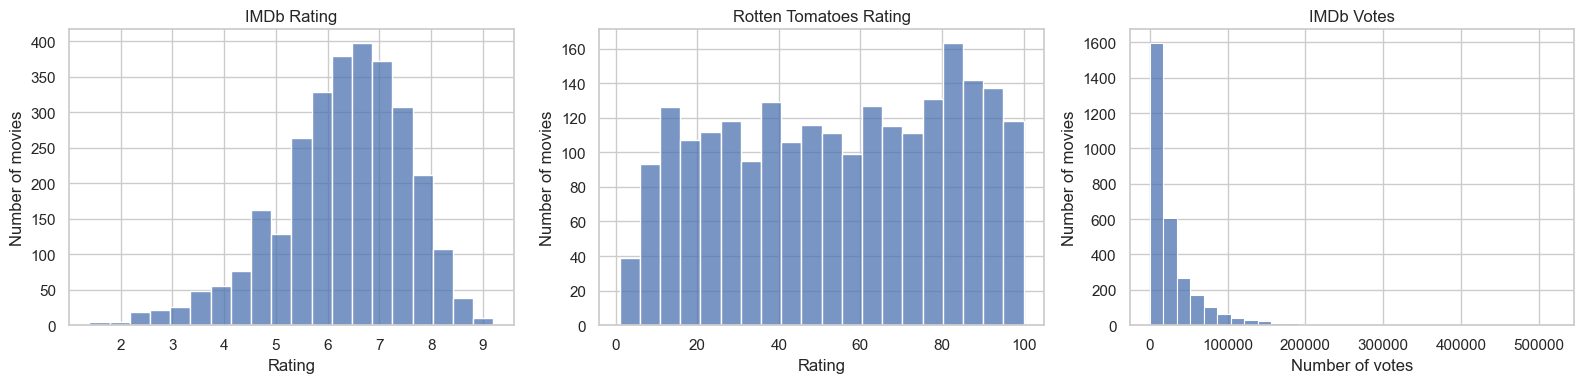

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=movies, x="imdb_rating", bins=20, ax=axes[0])
axes[0].set_title("IMDb Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of movies")

sns.histplot(data=movies, x="rotten_tomatoes_rating", bins=20, ax=axes[1])
axes[1].set_title("Rotten Tomatoes Rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of movies")

sns.histplot(data=movies, x="imdb_votes", bins=30, ax=axes[2])
axes[2].set_title("IMDb Votes")
axes[2].set_xlabel("Number of votes")
axes[2].set_ylabel("Number of movies")

plt.tight_layout()
plt.show()

## Movies by Genre

Genre counts describe the composition of the dataset. They should not be interpreted as market share because the dataset may not represent all movies released during the period.

In [10]:
genre_counts = (
    movies["major_genre"]
    .dropna()
    .value_counts()
    .rename_axis("major_genre")
    .reset_index(name="movie_count")
)

genre_counts

,major_genre,movie_count
0,Drama,785
1,Comedy,673
2,Action,418
3,Adventure,268
4,Thriller/Suspense,239
5,Horror,210
6,Romantic Comedy,137
7,Musical,53
8,Documentary,43
9,Black Comedy,36


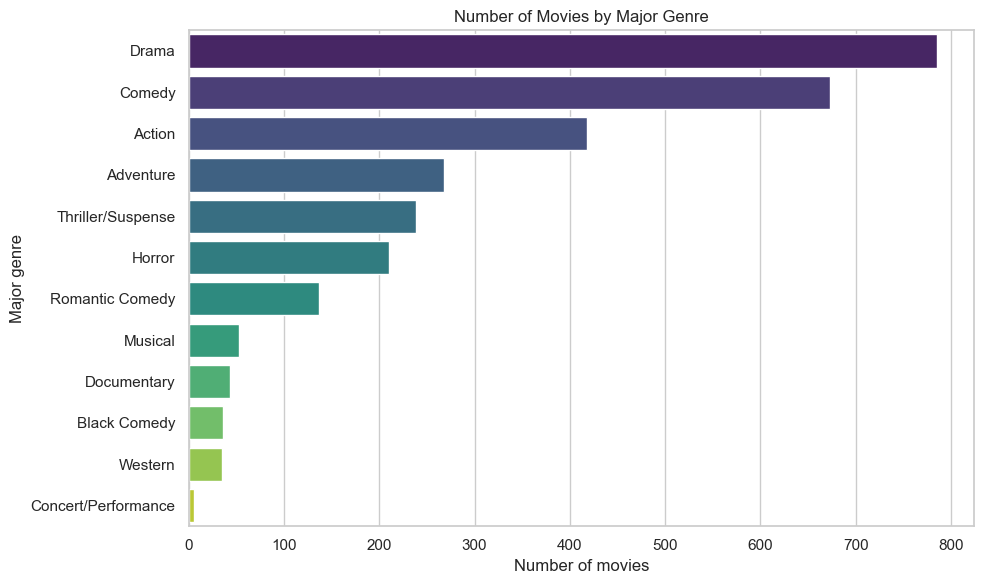

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=genre_counts,
    y="major_genre",
    x="movie_count",
    hue="major_genre",
    legend=False,
    palette="viridis",
    ax=ax,
)
ax.set_title("Number of Movies by Major Genre")
ax.set_xlabel("Number of movies")
ax.set_ylabel("Major genre")
plt.tight_layout()
plt.show()

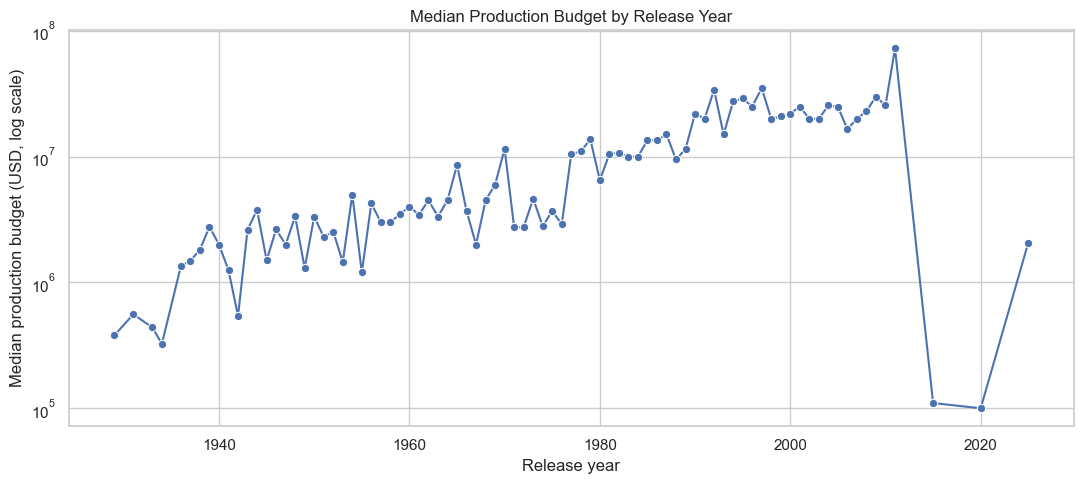

In [12]:
budget_by_year = movies.dropna(subset=["release_year", "production_budget"]).copy()
budget_by_year = budget_by_year[budget_by_year["production_budget"] > 0].copy()
budget_by_year["release_year"] = budget_by_year["release_year"].astype(int)

annual_budget = (
    budget_by_year.groupby("release_year", as_index=False)["production_budget"]
    .median()
    .rename(columns={"production_budget": "median_production_budget"})
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=annual_budget, x="release_year", y="median_production_budget", marker="o", ax=ax)
ax.set_yscale("log")
ax.set_title("Median Production Budget by Release Year")
ax.set_xlabel("Release year")
ax.set_ylabel("Median production budget (USD, log scale)")
plt.tight_layout()
plt.show()

## Production Budget and Worldwide Gross

Financial variables are strongly skewed, so a log-log view makes the relationship easier to inspect across small and large productions.

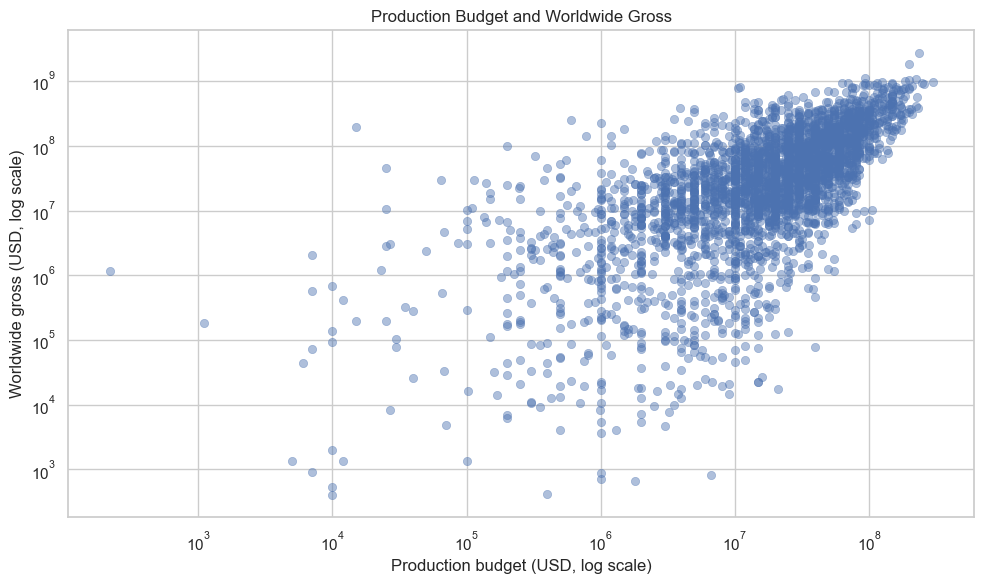

In [13]:
budget_revenue = movies.dropna(subset=["production_budget", "worldwide_gross"]).copy()
budget_revenue = budget_revenue[
    (budget_revenue["production_budget"] > 0)
    & (budget_revenue["worldwide_gross"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=budget_revenue,
    x="production_budget",
    y="worldwide_gross",
    alpha=0.45,
    edgecolor=None,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Production Budget and Worldwide Gross")
ax.set_xlabel("Production budget (USD, log scale)")
ax.set_ylabel("Worldwide gross (USD, log scale)")
plt.tight_layout()
plt.show()

In [14]:
relationship_summary = (
    movies[["production_budget", "worldwide_gross", "imdb_votes", "imdb_rating"]]
    .corr(method="spearman")
    .round(2)
)

print("Spearman rank correlations using pairwise complete observations:")
relationship_summary

Spearman rank correlations using pairwise complete observations:


,production_budget,worldwide_gross,imdb_votes,imdb_rating
production_budget,1.00,0.67,0.43,-0.09
worldwide_gross,0.67,1.00,0.66,0.14
imdb_votes,0.43,0.66,1.00,0.46
imdb_rating,-0.09,0.14,0.46,1.00


In [15]:
votes_revenue = movies.dropna(subset=["imdb_votes", "worldwide_gross"]).copy()
votes_revenue = votes_revenue[
    (votes_revenue["imdb_votes"] > 0)
    & (votes_revenue["worldwide_gross"] > 0)
].copy()

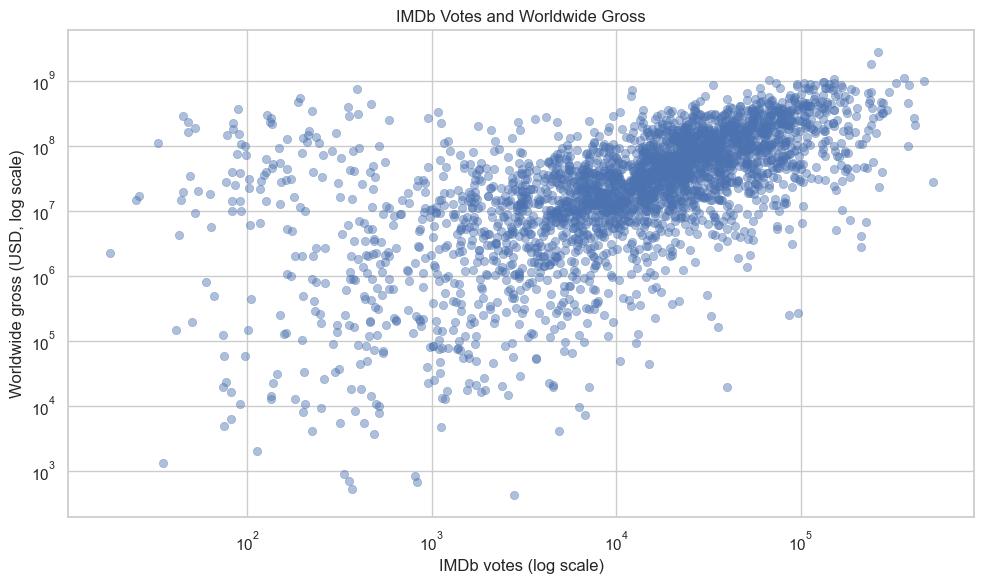

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=votes_revenue,
    x="imdb_votes",
    y="worldwide_gross",
    alpha=0.45,
    edgecolor=None,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("IMDb Votes and Worldwide Gross")
ax.set_xlabel("IMDb votes (log scale)")
ax.set_ylabel("Worldwide gross (USD, log scale)")
plt.tight_layout()
plt.show()

## Association Summary and Limitations

The visualizations help identify patterns, but this is an observational dataset. The results do not establish causation. Important limitations include missing values, possible selection bias, inflation across release years, differences in marketing and distribution, and the fact that genre labels and audience ratings are not perfectly standardized.

The analysis should report sample sizes alongside any correlation or group comparison. In particular, log-scale plots exclude records with missing or non-positive values because logarithms are undefined for those values.

In [17]:
analysis_columns = [
    "title",
    "release_year",
    "production_budget",
    "worldwide_gross",
    "major_genre",
    "imdb_rating",
    "imdb_votes",
    "rotten_tomatoes_rating",
]

print("Descriptive summary of selected analysis fields:")
movies[analysis_columns].describe(include="all").T

Descriptive summary of selected analysis fields:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,3169,3169,The Land Girls,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,3163.0,<NA>,<NA>,<NA>,1997.986721,12.065988,1929.0,1996.0,2001.0,2005.0,2025.0
production_budget,3169.0,NaN,NaN,NaN,30971367.222468,35327527.830425,218.0,6800000.0,20000000.0,42000000.0,300000000.0
worldwide_gross,3170.0,NaN,NaN,NaN,84784331.062776,148924494.740061,0.0,8006468.0,30770183.0,96725475.5,2767891499.0
major_genre,2902,12,Drama,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imdb_rating,2960.0,NaN,NaN,NaN,6.284696,1.25215,1.4,5.6,6.4,7.2,9.2
imdb_votes,2960.0,NaN,NaN,NaN,29894.397973,44977.592952,18.0,4797.5,15106.0,35810.5,519541.0
rotten_tomatoes_rating,2295.0,NaN,NaN,NaN,54.285403,28.074211,1.0,30.0,55.0,80.0,100.0
